# 1. Benchmark of force-indentation frameworks

In this notebook, we compare the performance of ForceIndent-JAX with ViscoIndent, which, to our knowledge, is the only other framework currently able to numerically simulate force-indentation data for a wide variety of constitutive models.

In [13]:
%run _common.ipynb
%matplotlib inline
import jax
import jax.numpy as jnp
from jax.scipy.special import beta, betainc
from jaxtyping import Float, Array
import numpy as np
import equinox as eqx
import matplotlib.pyplot as plt

from neuralconstitutive.indentation import (
    Constant,
    ConstantVelocity,
    IndentationBuilder,
    ApproachRetract,
    AbstractIndentation
)
from neuralconstitutive.tipgeometry import AbstractTipGeometry, Spherical, Conical
from neuralconstitutive.constitutive import AbstractConstitutive, Hertzian, PowerLaw
from neuralconstitutive.ting.numerical import force_ting
from ViscoIndent.Ting_numerical import ting_numerical

## ForceIndent-JAX

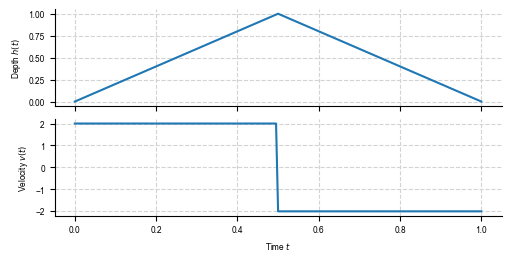

In [55]:
tip = Spherical(r=1.0)
indentation = (
    IndentationBuilder()
    .append(ConstantVelocity(velocity_=2.0), duration=0.5)
    .append(ConstantVelocity(velocity_=-2.0), duration=0.5)
    .build()
)
dt = 5e-3
t = jnp.arange(0.0, 1.0 + dt, dt)
h_t = jax.vmap(indentation.depth)(t)
v_t = jax.vmap(indentation.velocity)(t)

# Inspect the resulting indentation
fig, axes = plt.subplots(2, 1, figsize=(5, 2.5), sharex=True)
ylabels = ("Depth $h(t)$", "Velocity $v(t)$")
for ax, y, ylabel in zip(axes, (h_t, v_t), ylabels):
    ax.plot(t, y)
    ax.set_ylabel(ylabel)
axes[1].set_xlabel("Time $t$")

powerlaw = PowerLaw(E0=3.0, alpha=0.2)

In [56]:
# %%timeit
f_powerlaw = eqx.filter_jit(force_ting)(t, powerlaw, indentation, tip)

## ViscoIndent

Before our experiment, we define some utility functions

In [57]:
def tipgeometry_to_viscoindent_args(tip: AbstractTipGeometry) -> tuple[str, float]:
    match tip:
        case Spherical(r=r_):
            modelprobe = "sphere"
            probe_size = r_
        case Conical(theta=theta_):
            modelprobe = "cone"
            probe_size = theta_ * 180 / jnp.pi
        case _:
            raise ValueError("Unsupported tip shape!")
    return modelprobe, float(probe_size)


def constitutive_to_viscoindent_args(
    constit: AbstractConstitutive,
) -> tuple[str, list[float]]:
    match constit:
        case Hertzian(E0=E0_):
            modelting = "elastic"
            model_params = [E0_]
        case PowerLaw(E0=E0_, alpha=alpha_):
            modelting = "springpot"
            model_params = [E0_, alpha_]
        case _:
            raise ValueError("Unsupported constitutive equation!")
    model_params = list(map(float, model_params))
    return modelting, model_params


def force_viscoindent(
    time: Float[Array, " N"],
    constit: AbstractConstitutive,
    indentation: AbstractIndentation,
    tip: AbstractTipGeometry,
) -> Float[Array, " N"]:
    modelting, model_params = constitutive_to_viscoindent_args(constit)
    modelprobe, probe_size = tipgeometry_to_viscoindent_args(tip)
    dt = float(time[1] - time[0])
    max_ind = int(jnp.argmin(jnp.abs(time - indentation.t_ret)))
    depth_array = np.asarray(jax.vmap(indentation.depth)(time))
    force, *_ = ting_numerical(
        model_params,
        None,
        0.5,
        probe_size,
        dt,
        max_ind,
        0,
        modelting,
        modelprobe,
        depth_array,
    )
    return force

We also define a function (and associated helper functions) to calculate the analytical solution for the force, again with the same signature as `force_ting` and `force_viscoindent` functions

In [58]:
f_viscoindent = force_viscoindent(t, powerlaw, indentation, tip)

In [59]:
def t1_analytic(
    t: Float[Array, " N"],
    constit: AbstractConstitutive,
    indentation: AbstractIndentation,
) -> Float[Array, " N"]:
    if isinstance(constit, PowerLaw) and isinstance(indentation, ApproachRetract):
        const = 2 ** (1 / (1 - constit.alpha))
        return jnp.clip(t - const * (t - indentation.t_ret), 0.0)
    else:
        raise ValueError(
            "Analytic solution unknown for the given combination of constitutive model and indentation!"
        )


def force_analytic(
    time: Float[Array, " N"],
    constit: AbstractConstitutive,
    indentation: AbstractIndentation,
    tip: AbstractTipGeometry,
) -> Float[Array, " N"]:
    if isinstance(constit, PowerLaw) and isinstance(indentation, ApproachRetract):
        v = indentation.approach.velocity_
        a, b = tip.a(), tip.b()
        coeff = a * b * constit.E0 * (v**b) * beta(1 - constit.alpha, b)
        force = coeff * (time ** (b - constit.alpha))
        t1 = t1_analytic(time, constit, indentation)
        correction_factor = jnp.where(
            time <= indentation.t_ret, 1.0, betainc(b, 1 - constit.alpha, t1 / t)
        )
        return force * correction_factor
    else:
        raise ValueError(
            "Analytic solution unknown for the given combination of constitutive model and indentation!"
        )

In [60]:
f_analytic = force_analytic(t, powerlaw, indentation, tip)

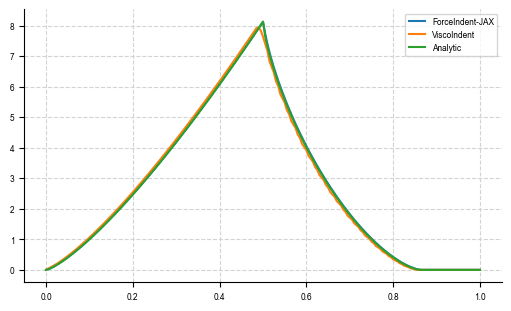

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(t, f_powerlaw, label="ForceIndent-JAX")
ax.plot(t, f_viscoindent, label="ViscoIndent")
ax.plot(t, f_analytic, label="Analytic")
ax.legend()

In [25]:
def SMAPE(y_pred, y_true):
    numer = jnp.abs(y_pred - y_true)
    denom = 0.5 * (jnp.abs(y_pred) + jnp.abs(y_true))
    denom = jnp.where(
        denom == 0.0, 1.0, denom
    )  # Replace zero denominator with dummy value
    return 100 * jnp.mean(numer / denom)

In [26]:
print(SMAPE(f_powerlaw, f_analytic))
print(SMAPE(f_viscoindent, f_analytic))

1.321163298802764
7.537000339025673
